# Phase 2: Accident Cause Code EDA

This notebook continues the analysis started in `phase-1-proposal.ipynb`.
Phase 1 established that metro and rural counties have fundamentally different
accident patterns - both in frequency and cause distribution. 

The goal here is to identify the **top 5 features** that influence accident
cause codes (H, M, T, E, S) through exploratory data analysis. This work
supports the classification track of our Phase 2 parallel analysis, alongside
Tim and Matt's damage cost investigation.

## Setup & Data Loading

Loading the processed merged dataframe from Phase 1. This is the cleaned
dataset saved from V2 after the FRA accident data was merged with USDA
county-level population and rural-urban classifications.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load processed merged dataframe
df_merged = pd.read_csv("../data/processed/df_merged.csv.zip")

# Quick check
print(f"Shape: {df_merged.shape}")
df_merged.head()

Shape: (34562, 161)


/var/folders/h7/j749vy8n45n8p147xy2ll3vw0000gn/T/ipykernel_48730/1285605260.py:9: DtypeWarning: Columns (26,28,48,68,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df_merged = pd.read_csv("../data/processed/df_merged.csv.zip")


,Reporting Railroad Code,Reporting Railroad Name,Year,Accident Number,PDF Link,Accident Year,Accident Month,Other Railroad Code,Other Railroad Name,Other Accident Number,...,Reporting Railroad Tourist,Reporting Railroad Freight,Reporting Railroad Short Line,Location,State Code FIPS,County Code FIPS,FIPS,Description,Population_2020,RUCC_2023
0,BNSF,BNSF Railway Company,2013,NW0813104,https://safetydata.fra.dot.gov/Officeofsafety/...,13,8,NaN,NaN,NaN,...,Unassigned,Yes,Unassigned,POINT (-122.388591 47.248398),53,53,53053,Metro - Counties in metro areas of 1 million p...,921130.0,1
1,CSX,CSX Transportation,2014,000131012,https://safetydata.fra.dot.gov/Officeofsafety/...,14,6,NaN,NaN,NaN,...,Unassigned,Yes,Unassigned,POINT (-84.688394 38.794404),21,15,21015,Metro - Counties in metro areas of 1 million p...,135968.0,1
2,CSX,CSX Transportation,2020,000191201,https://safetydata.fra.dot.gov/Officeofsafety/...,20,7,NaN,NaN,NaN,...,Unassigned,Yes,Unassigned,POINT (-86.770737 36.112142),47,37,47037,Metro - Counties in metro areas of 1 million p...,715884.0,1
3,CSX,CSX Transportation,2013,000121335,https://safetydata.fra.dot.gov/Officeofsafety/...,13,10,NaN,NaN,NaN,...,Unassigned,Yes,Unassigned,POINT (-82.18718 34.176627),45,47,45047,"Nonmetro - Urban population of 20,000 or more,...",69351.0,4
4,SFRV,South Florida Regional Transportation Authority,2024,03172024,https://safetydata.fra.dot.gov/Officeofsafety/...,24,3,NaN,NaN,NaN,...,Yes,Unassigned,Unassigned,POINT (-80.07352 26.7564),12,99,12099,Metro - Counties in metro areas of 1 million p...,1492191.0,1


## Recreating Cause Category

The `Cause_Category` column wasn't saved in the processed CSV - it was
created in V2 by grabbing the first letter of `Primary Accident Cause Code`.
Recreating it here so we can work with it.

In [ ]:
# Recreate Cause_Category from Primary Accident Cause Code
df_merged['Cause_Category'] = df_merged['Primary Accident Cause Code'].str[0]

# Now check the distribution
print(df_merged['Cause_Category'].value_counts())

Cause_Category
H    13582
M     8856
T     7534
E     3721
S      867
Name: count, dtype: int64


## Cause Category Distribution

Visualizing our target variable. Important to see the balance across
categories before moving into feature exploration - imbalanced classes
can affect classification later.

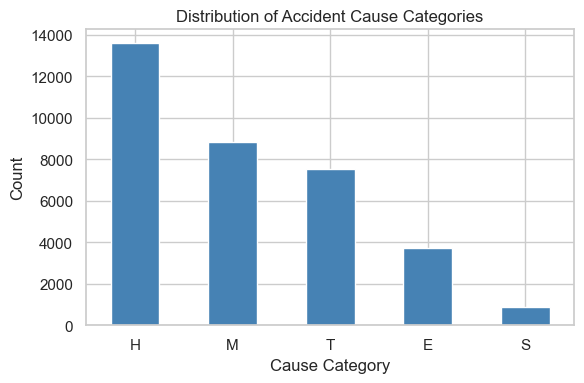

In [11]:
# Visualize cause category distribution
plt.figure(figsize=(6, 4))
df_merged['Cause_Category'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribution of Accident Cause Categories')
plt.xlabel('Cause Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Exploring Categorical Features

First, let's see what string columns we're working with before deciding
which ones are worth converting to numerical values.

In [13]:
df_merged.select_dtypes(include='object').columns.tolist()

['Reporting Railroad Code',
 'Reporting Railroad Name',
 'Accident Number',
 'PDF Link',
 'Other Railroad Code',
 'Other Railroad Name',
 'Other Accident Number',
 'Maintenance Railroad Code',
 'Maintenance Railroad Name',
 'Maintenance Accident Number',
 'Grade Crossing ID',
 'Date',
 'Time',
 'Accident Type',
 'Persons Evacuated',
 'Subdivision',
 'Division Code',
 'Station',
 'Milepost',
 'State Abbreviation',
 'State Name',
 'County Name',
 'Visibility',
 'Weather Condition',
 'Track Type',
 'Track Name',
 'Track Class',
 'Track Density',
 'Train Direction Code',
 'Train Direction',
 'Equipment Type Code',
 'Equipment Type',
 'Equipment Attended',
 'Train Number',
 'Recorded Estimated Speed',
 'Gross Tonnage',
 'Signalization',
 'Method of Operation',
 'Adjunct Code 1',
 'Adjunct Name 1',
 'Adjunct Code 2',
 'Adjunct Name 2',
 'Adjunct Code 3',
 'Adjunct Name 3',
 'Remote Control Locomotive Code',
 'Remote Control Locomotive',
 'First Car Initials',
 'First Car Number',
 'First Car

## Identifying Candidate Features for Encoding

Scanning categorical columns to see which ones have a manageable number of
unique values - good candidates for label encoding.

In [23]:
# Viewa few candidates up close
candidates = ['Accident Type', 'Weather Condition', 'Track Type', 'Visibility', 'State Abbreviation']

for col in candidates:
    print(f"\n{col} - unique values: {df_merged[col].nunique()}")
    print(df_merged[col].value_counts().head())


Accident Type - unique values: 13
Accident Type
Derailment                       19113
Other impacts                     5114
Hwy-rail crossing                 3294
Other (describe in narrative)     2155
Side collision                    1689
Name: count, dtype: int64

Weather Condition - unique values: 6
Weather Condition
Clear     23402
Cloudy     7692
Rain       2422
Snow        643
Fog         324
Name: count, dtype: int64

Track Type - unique values: 4
Track Type
Yard        19236
Main        11644
Industry     2893
Siding        787
Name: count, dtype: int64

Visibility - unique values: 4
Visibility
Day     15515
Dark    12227
Dawn     3512
Dusk     3300
Name: count, dtype: int64

State Abbreviation - unique values: 49
State Abbreviation
TX    4220
IL    2816
CA    2130
OH    1334
IN    1308
Name: count, dtype: int64


## Checking Visibility

Quick look at Visibility - unique values and distribution before encoding.

In [15]:
print(f"Visibility - unique values: {df_merged['Visibility'].nunique()}")
print(df_merged['Visibility'].value_counts())

Visibility - unique values: 4
Visibility
Day     15515
Dark    12227
Dawn     3512
Dusk     3300
Name: count, dtype: int64


## Label Encoding Categorical Features

Correlation matrices require numerical inputs, so we convert key categorical
features into numbers using Label Encoding. Each unique category gets assigned
an integer value.

**Note:** `nan` values are getting their own encoded value in each column.
This will need to be addressed later in preprocessing.

In [18]:
from sklearn.preprocessing import LabelEncoder

# Columns to encode
cols_to_encode = ['Weather Condition', 'Track Type', 'Visibility', 'Accident Type']

# Create a copy so we don't mess with the original
df_encoded = df_merged.copy()

# Label encode each column
le = LabelEncoder()
for col in cols_to_encode:
    df_encoded[col + '_encoded'] = le.fit_transform(df_merged[col].astype(str))
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Weather Condition: {'Clear': 0, 'Cloudy': 1, 'Fog': 2, 'Rain': 3, 'Sleet': 4, 'Snow': 5, 'nan': 6}
Track Type: {'Industry': 0, 'Main': 1, 'Siding': 2, 'Yard': 3, 'nan': 4}
Visibility: {'Dark': 0, 'Dawn': 1, 'Day': 2, 'Dusk': 3, 'nan': 4}
Accident Type: {'Broken train collision': 0, 'Derailment': 1, 'Explosion-detonation': 2, 'Fire/violent rupture': 3, 'Head on collision': 4, 'Hwy-rail crossing': 5, 'Obstruction': 6, 'Other (describe in narrative)': 7, 'Other impacts': 8, 'RR grade crossing': 9, 'Raking collision': 10, 'Rear end collision': 11, 'Side collision': 12, 'nan': 13}


## Correlation Matrix - Relevant Features

We check how candidate features relate to each other to spot redundancy early.
If two features are highly correlated, they're telling the same story and we may
only need one.

**Key findings:**
- **Track Type & Train Speed (-0.38):** Yard tracks run slower than mainlines -
partially redundant.
- **Population & RUCC (-0.37):** Expected overlap - may only need one.
- **Everything else:** Near-zero correlation, meaning each feature brings something
unique to the classification task.

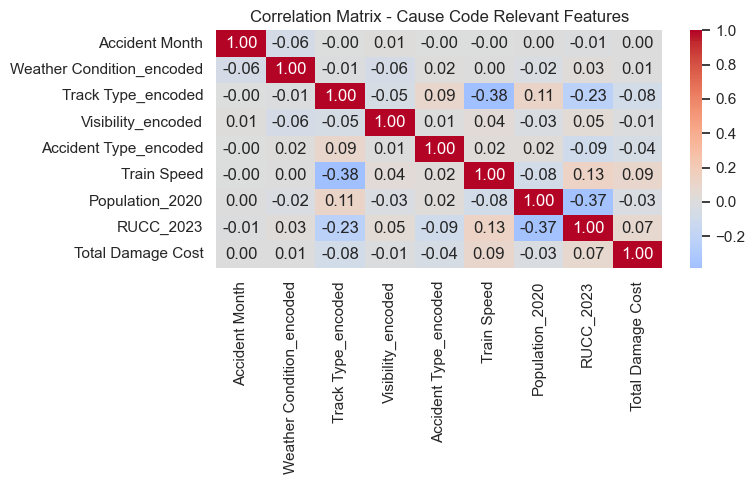

In [22]:
# Clean Total Damage Cost - remove commas and convert to number
df_encoded['Total Damage Cost'] = pd.to_numeric(
    df_encoded['Total Damage Cost'].astype(str).str.replace(',', ''), 
    errors='coerce'
)

# Narrow down to features relevant to cause code prediction
relevant_cols = [
    'Accident Month',
    'Weather Condition_encoded',
    'Track Type_encoded',
    'Visibility_encoded',
    'Accident Type_encoded',
    'Train Speed',
    'Population_2020',
    'RUCC_2023',
    'Total Damage Cost'
]

# Create focused correlation matrix
corr_focused = df_encoded[relevant_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr_focused, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Cause Code Relevant Features')
plt.tight_layout()
plt.show()

## Track Type vs Cause Category

Examining how accident cause categories distribute across different track
types. Each bar group adds to 100%, so we're comparing proportions not
raw counts.

**Key takeaway:** Mainline tracks are dominated by Mechanical failures,
while Yard and Industry tracks show higher Human Factor rates. This makes
operational sense - mainlines run high-speed freight while yards rely
heavily on manual switching movements.

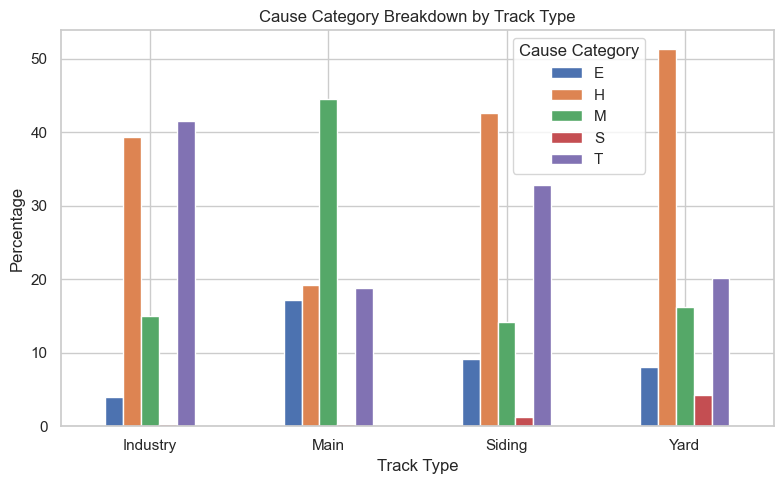

In [36]:
# Track Type vs Cause Category
plt.figure(figsize=(8, 5))
ct = pd.crosstab(df_merged['Track Type'], df_merged['Cause_Category'], normalize='index') * 100
ct.plot(kind='bar', ax=plt.gca())
plt.title('Cause Category Breakdown by Track Type')
plt.xlabel('Track Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Cause Category', loc='upper right', bbox_to_anchor=( .83, 1))
plt.tight_layout()
plt.show()

## RUCC Code vs Cause Category

Looking at how cause categories shift across the metro-to-rural spectrum.
This builds on Phase 1's statistical finding that metro and rural counties
have fundamentally different accident patterns.

**Key takeaway:** Metro counties (RUCC 1-3) are dominated by Human Factor
causes, while rural counties (RUCC 7-9) show a clear increase in Track and
Mechanical failures. The middle RUCC codes (4-6) act as a transition zone
where causes are more evenly distributed.

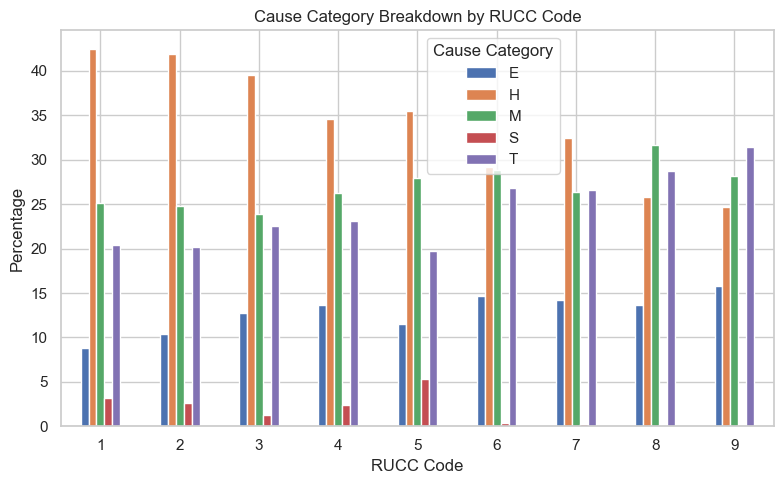

In [43]:
# RUCC vs Cause Category
plt.figure(figsize=(8, 5))
ct_rucc = pd.crosstab(df_merged['RUCC_2023'], df_merged['Cause_Category'], normalize='index') * 100
ct_rucc.plot(kind='bar', ax=plt.gca())
plt.title('Cause Category Breakdown by RUCC Code')
plt.xlabel('RUCC Code')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Cause Category', loc='upper right', bbox_to_anchor=( .71, 1))
plt.tight_layout()
plt.show()

## Accident Month vs Cause Category

Checking for seasonal patterns in cause code distribution. The hypothesis
was that certain causes (Track failures, Environmental) might shift with
seasons due to weather and infrastructure stress.

**Key takeaway:** Cause category proportions remain relatively stable
across all 12 months. Accident Month does not appear to be a strong
predictor of cause codes. This is useful to know - it helps us focus
on the features that actually matter (Track Type, RUCC) going forward.

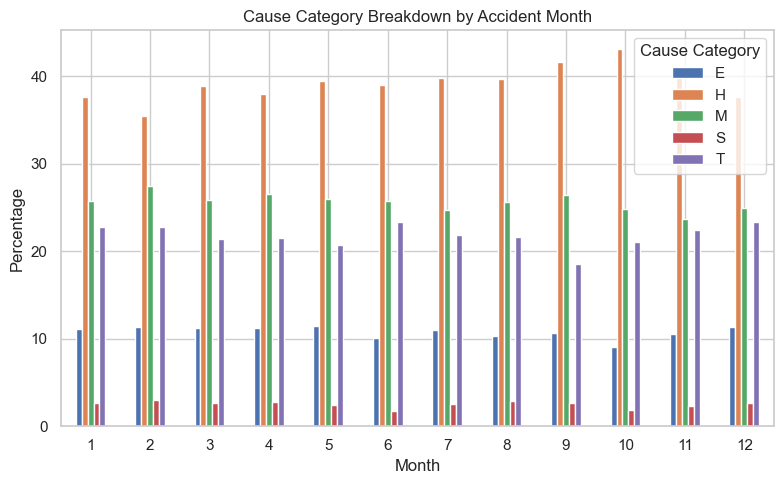

In [44]:
# Accident Month vs Cause Category
plt.figure(figsize=(8, 5))
ct_month = pd.crosstab(df_merged['Accident Month'], df_merged['Cause_Category'], normalize='index') * 100
ct_month.plot(kind='bar', ax=plt.gca())
plt.title('Cause Category Breakdown by Accident Month')
plt.xlabel('Month')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Cause Category')
plt.tight_layout()
plt.show()

# Phase 2: Cause Code EDA - Summary

## What We Did

Starting from the cleaned merged dataframe produced in Phase 1, we explored
three features to understand which ones show meaningful differences across
the five accident cause categories (H, M, T, E, S).

1. **Correlation Matrix** - Checked relationships between numerical features
to identify redundancy. Found Track Type/Train Speed and Population/RUCC
are partially redundant pairs.

2. **Track Type vs Cause Category** - Mainline tracks are dominated by
Mechanical failures, while Yards and Industry tracks show higher Human
Factor rates. Strong signal for classification.

3. **RUCC Code vs Cause Category** - Metro counties (1-3) are dominated
by Human Factor causes, while rural counties (7-9) show increasing Track
and Mechanical failures. Visually confirms Phase 1's statistical findings.

4. **Accident Month vs Cause Category** - Cause proportions remain stable
across all 12 months. Month does not appear to be a strong predictor -
useful to know what to deprioritize.

## Key Takeaways

- **Track Type** and **RUCC Code** are the strongest candidates for
cause code classification so far
- **Accident Month** can likely be deprioritized
- Due to redundancy, we likely only need one of Population/RUCC and one
of Track Type/Train Speed going forward

## Possible Next Steps

- Begin feature selection - narrow down to the most useful features
before moving into classification
- Coordinate with the team on shared preprocessing decisions
(e.g., handling the nan values in encoded columns)
- Consider a simple baseline classifier (e.g., Logistic Regression)
to establish a benchmark before trying more complex models